# Minería de Datos — Ejercicio Integrador 5
### Segmentación de Clientes con Clustering — UCI Online Retail Dataset
**Nombre:** Gallego Ian | **Institución:** Politécnico Malvinas Argentinas | **Año:** 2026

---
**Contexto:** Trabajamos en el departamento de análisis de datos de una empresa de e-commerce.
El objetivo es identificar grupos de clientes con patrones de compra similares para diseñar
estrategias de marketing personalizadas, utilizando el **UCI Online Retail Dataset** (transacciones
de una tienda online británica, 2010–2011).

---
## Tarea 1 — Preprocesamiento de Datos
**Pasos:**
1. Eliminar valores nulos y registros con cantidades negativas.
2. Agrupar por `CustomerID` para obtener: `TotalCompras`, `CantidadTotal`, `GastoTotal` y `Frecuencia`.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('Online Retail.xlsx')

print('=== Dataset original ===')
print(f'Filas: {len(df):,}  |  Columnas: {df.shape[1]}')
print('Valores nulos:')
print(df.isnull().sum())
print(f'Quantity < 0 (devoluciones): {(df["Quantity"] < 0).sum():,}')

=== Dataset original ===
Filas: 541,909  |  Columnas: 8
Valores nulos:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Quantity < 0 (devoluciones): 10,624


In [2]:
# Limpieza
df_limpio = df.dropna(subset=['CustomerID', 'Description']).copy()
df_limpio = df_limpio[df_limpio['Quantity'] > 0]
df_limpio = df_limpio[df_limpio['UnitPrice'] > 0]
df_limpio = df_limpio.drop_duplicates()
df_limpio['CustomerID'] = df_limpio['CustomerID'].astype(int)
df_limpio['TotalVenta'] = df_limpio['Quantity'] * df_limpio['UnitPrice']

print(f'Filas originales:    {len(df):>7,}')
print(f'Filas tras limpieza: {len(df_limpio):>7,}')
print(f'Filas eliminadas:    {len(df) - len(df_limpio):>7,}')

Filas originales:    541,909
Filas tras limpieza: 392,692
Filas eliminadas:    149,217


In [3]:
# Agregar metricas por cliente
df_clientes = df_limpio.groupby('CustomerID').agg(
    TotalCompras  = ('InvoiceNo',  'nunique'),
    CantidadTotal = ('Quantity',   'sum'),
    GastoTotal    = ('TotalVenta', 'sum')
).reset_index()

print('=== Metricas por cliente ===')
print(f'Clientes unicos: {len(df_clientes):,}')
print(df_clientes.describe())

=== Metricas por cliente ===
Clientes unicos: 4,338
         CustomerID  TotalCompras  CantidadTotal     GastoTotal
count   4338.000000   4338.000000    4338.000000    4338.000000
mean   15300.408022      4.272015    1187.644537    2048.688081
std     1721.808492      7.697998    5043.619654    8985.230220
min    12346.000000      1.000000       1.000000       3.750000
25%    13813.250000      1.000000     159.000000     306.482500
50%    15299.500000      2.000000     378.000000     668.570000
75%    16778.750000      5.000000     989.750000    1660.597500
max    18287.000000    209.000000  196915.000000  280206.020000


---
## Tarea 2 — Codificación y Normalización
1. Convertir `Frecuencia` en variable ordinal por terciles: **Baja=0 / Media=1 / Alta=2**
   (basada en `TotalCompras`).
2. Normalizar `CantidadTotal` y `GastoTotal` con **MinMaxScaler**.

In [4]:
from sklearn.preprocessing import MinMaxScaler

# Frecuencia ordinal por terciles de TotalCompras
tercil_bajo = df_clientes['TotalCompras'].quantile(1/3)
tercil_alto  = df_clientes['TotalCompras'].quantile(2/3)

def categorizar_frecuencia(x):
    if x <= tercil_bajo:
        return 0  # Baja
    elif x <= tercil_alto:
        return 1  # Media
    else:
        return 2  # Alta

df_clientes['Frecuencia'] = df_clientes['TotalCompras'].apply(categorizar_frecuencia)

print('Distribucion de Frecuencia (0=Baja, 1=Media, 2=Alta):')
print(df_clientes['Frecuencia'].value_counts().sort_index())
print('')
print('Umbral Baja<=Media:', round(tercil_bajo, 1), 'compras')
print('Umbral Media<=Alta:', round(tercil_alto, 1), 'compras')

Distribucion de Frecuencia (0=Baja, 1=Media, 2=Alta):
Frecuencia
0    1493
1    1731
2    1114
Name: count, dtype: int64

Umbral Baja<=Media: 1.0 compras
Umbral Media<=Alta: 4.0 compras


In [5]:
# Normalizar CantidadTotal y GastoTotal
scaler = MinMaxScaler()
df_clientes[['CantidadTotal_norm', 'GastoTotal_norm']] = scaler.fit_transform(
    df_clientes[['CantidadTotal', 'GastoTotal']]
)

# Matriz de features para clustering
X = df_clientes[['CantidadTotal_norm', 'GastoTotal_norm', 'Frecuencia']].values

print('=== Features para clustering ===')
print(pd.DataFrame(X, columns=['CantidadTotal_norm','GastoTotal_norm','Frecuencia']).describe().round(3))

=== Features para clustering ===
       CantidadTotal_norm  GastoTotal_norm  Frecuencia
count            4338.000         4338.000    4338.000
mean                0.006            0.007       0.913
std                 0.026            0.032       0.770
min                 0.000            0.000       0.000
25%                 0.001            0.001       0.000
50%                 0.002            0.002       1.000
75%                 0.005            0.006       2.000
max                 1.000            1.000       2.000


---
## Tarea 3 — Aplicación de Algoritmos de Clustering
### 3.1 K-Means — Método del Codo

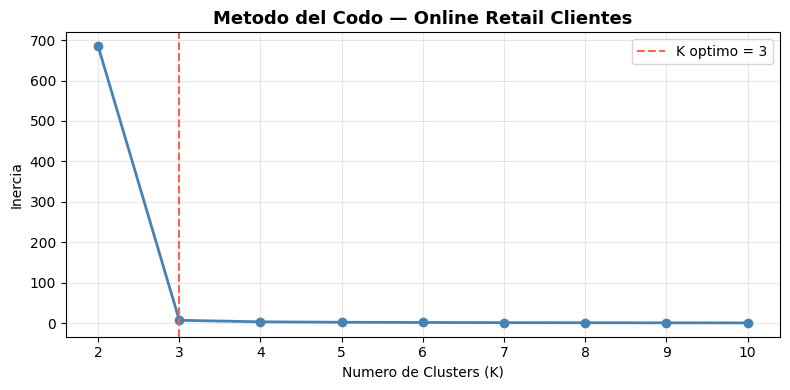

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercia = []
valores_k = range(2, 11)
for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inercia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(valores_k, inercia, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='tomato', linestyle='--', label='K optimo = 3')
plt.title('Metodo del Codo — Online Retail Clientes', fontsize=13, fontweight='bold')
plt.xlabel('Numero de Clusters (K)')
plt.ylabel('Inercia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# K-Means con K optimo = 3
K_OPTIMO = 3
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_clientes['Cluster_KMeans'] = kmeans.fit_predict(X)

print('Distribucion de clientes por cluster K-Means:')
print(df_clientes['Cluster_KMeans'].value_counts().sort_index())
print('')
print('Perfil medio por cluster:')
perfil = df_clientes.groupby('Cluster_KMeans')[['TotalCompras','CantidadTotal','GastoTotal','Frecuencia']].mean().round(1)
print(perfil)

Distribucion de clientes por cluster K-Means:
Cluster_KMeans
0    1731
1    1493
2    1114
Name: count, dtype: int64

Perfil medio por cluster:
                TotalCompras  CantidadTotal  GastoTotal  Frecuencia
Cluster_KMeans                                                     
0                        2.7          644.2      1121.2         1.0
1                        1.0          270.3       411.2         0.0
2                       11.0         3261.6      5684.4         2.0


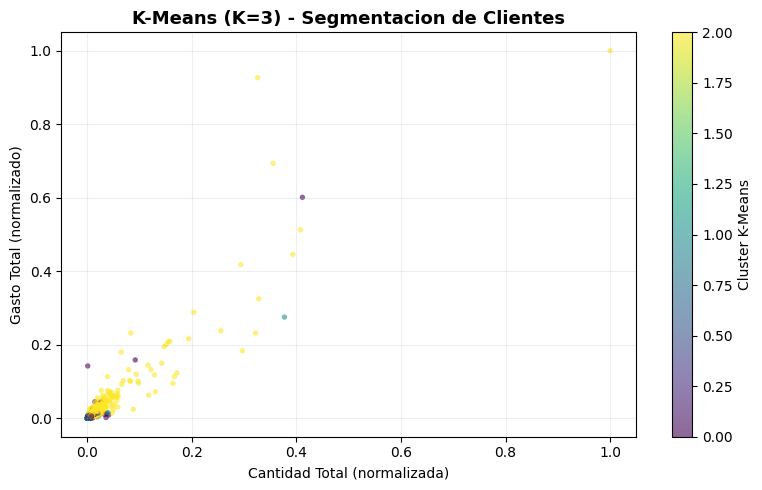

In [8]:
# Visualizacion K-Means
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df_clientes['CantidadTotal_norm'],
    df_clientes['GastoTotal_norm'],
    c=df_clientes['Cluster_KMeans'],
    cmap='viridis', s=15, alpha=0.6, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Cluster K-Means')
ax.set_title(f'K-Means (K={K_OPTIMO}) - Segmentacion de Clientes', fontsize=13, fontweight='bold')
ax.set_xlabel('Cantidad Total (normalizada)')
ax.set_ylabel('Gasto Total (normalizado)')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 3.2 DBSCAN — Detección de Clientes Outliers

Para elegir `eps` se usa el **gráfico k-distancia**: se ordena de mayor a menor la distancia al
5° vecino más cercano de cada punto. El codo de la curva indica el `eps` óptimo: por encima
de ese valor los puntos son outliers, por debajo son core points.

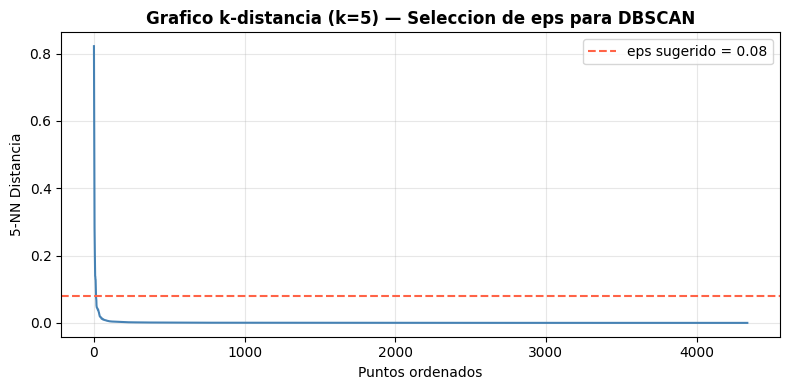

Nota: el codo esta cerca de 0.05-0.10; se usa eps=0.08


In [9]:
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X)
distancias, _ = nbrs.kneighbors(X)
distancias_ordenadas = np.sort(distancias[:, 4])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(distancias_ordenadas, color='steelblue', linewidth=1.5)
plt.axhline(y=0.08, color='tomato', linestyle='--', label='eps sugerido = 0.08')
plt.title('Grafico k-distancia (k=5) — Seleccion de eps para DBSCAN', fontsize=12, fontweight='bold')
plt.xlabel('Puntos ordenados')
plt.ylabel('5-NN Distancia')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Nota: el codo esta cerca de 0.05-0.10; se usa eps=0.08')

In [10]:
from sklearn.cluster import DBSCAN

# eps=0.08 corresponde al codo del grafico k-distancia
dbscan = DBSCAN(eps=0.08, min_samples=5)
df_clientes['Cluster_DBSCAN'] = dbscan.fit_predict(X)

n_clusters_db = len(set(df_clientes['Cluster_DBSCAN'])) - (1 if -1 in df_clientes['Cluster_DBSCAN'].values else 0)
n_outliers_db = (df_clientes['Cluster_DBSCAN'] == -1).sum()

print('DBSCAN — Clusters detectados :', n_clusters_db)
print('DBSCAN — Outliers (etiq. -1) :', n_outliers_db, f'({n_outliers_db/len(df_clientes)*100:.1f} %)')
print('')
print('Distribucion de clientes por cluster DBSCAN:')
print(df_clientes['Cluster_DBSCAN'].value_counts().sort_index())

DBSCAN — Clusters detectados : 3
DBSCAN — Outliers (etiq. -1) : 11 (0.3 %)

Distribucion de clientes por cluster DBSCAN:
Cluster_DBSCAN
-1      11
 0    1107
 1    1728
 2    1492
Name: count, dtype: int64


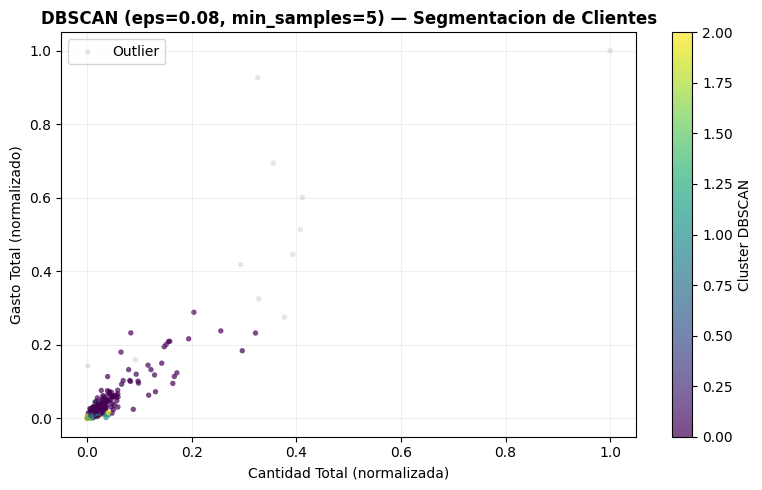

In [11]:
# Visualizacion DBSCAN
fig, ax = plt.subplots(figsize=(8, 5))

mask_out = df_clientes['Cluster_DBSCAN'] == -1
ax.scatter(
    df_clientes.loc[mask_out, 'CantidadTotal_norm'],
    df_clientes.loc[mask_out, 'GastoTotal_norm'],
    c='#cccccc', s=15, alpha=0.5, label='Outlier', edgecolors='none'
)
scatter = ax.scatter(
    df_clientes.loc[~mask_out, 'CantidadTotal_norm'],
    df_clientes.loc[~mask_out, 'GastoTotal_norm'],
    c=df_clientes.loc[~mask_out, 'Cluster_DBSCAN'],
    cmap='viridis', s=15, alpha=0.7, edgecolors='none'
)
plt.colorbar(scatter, ax=ax, label='Cluster DBSCAN')
ax.set_title('DBSCAN (eps=0.08, min_samples=5) — Segmentacion de Clientes', fontsize=12, fontweight='bold')
ax.set_xlabel('Cantidad Total (normalizada)')
ax.set_ylabel('Gasto Total (normalizado)')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

---
## Tarea 4 — Evaluación del Clustering
Comparar K-Means y DBSCAN usando **Silhouette Score** y **Davies-Bouldin Index**.

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# K-Means
sil_km = silhouette_score(X, df_clientes['Cluster_KMeans'])
dbi_km = davies_bouldin_score(X, df_clientes['Cluster_KMeans'])

# DBSCAN (excluir outliers)
mask_valid = df_clientes['Cluster_DBSCAN'] != -1
n_validos = mask_valid.sum()
n_clusters_validos = df_clientes.loc[mask_valid, 'Cluster_DBSCAN'].nunique()

if n_clusters_validos >= 2:
    sil_db = silhouette_score(X[mask_valid], df_clientes.loc[mask_valid, 'Cluster_DBSCAN'])
    dbi_db = davies_bouldin_score(X[mask_valid], df_clientes.loc[mask_valid, 'Cluster_DBSCAN'])
    dbscan_metrics = (sil_db, dbi_db)
else:
    dbscan_metrics = None

print('=== COMPARACION DE METRICAS DE CLUSTERING ===')
print('')
print(f'K-Means (K={K_OPTIMO}):')
print(f'  Silhouette Score     : {sil_km:.4f}  (mayor es mejor, max=1)')
print(f'  Davies-Bouldin Index : {dbi_km:.4f}  (menor es mejor, min=0)')
print('')
if dbscan_metrics:
    print('DBSCAN (eps=0.08, min_samples=5):')
    print(f'  Clientes en clusters : {n_validos:,} / {len(df_clientes):,}')
    print(f'  Clusters detectados  : {n_clusters_validos}')
    print(f'  Silhouette Score     : {dbscan_metrics[0]:.4f}')
    print(f'  Davies-Bouldin Index : {dbscan_metrics[1]:.4f}')
else:
    print('DBSCAN: no se pueden calcular metricas (menos de 2 clusters)')

=== COMPARACION DE METRICAS DE CLUSTERING ===

K-Means (K=3):
  Silhouette Score     : 0.9889  (mayor es mejor, max=1)
  Davies-Bouldin Index : 0.0234  (menor es mejor, min=0)

DBSCAN (eps=0.08, min_samples=5):
  Clientes en clusters : 4,327 / 4,338
  Clusters detectados  : 3
  Silhouette Score     : 0.9916
  Davies-Bouldin Index : 0.0168


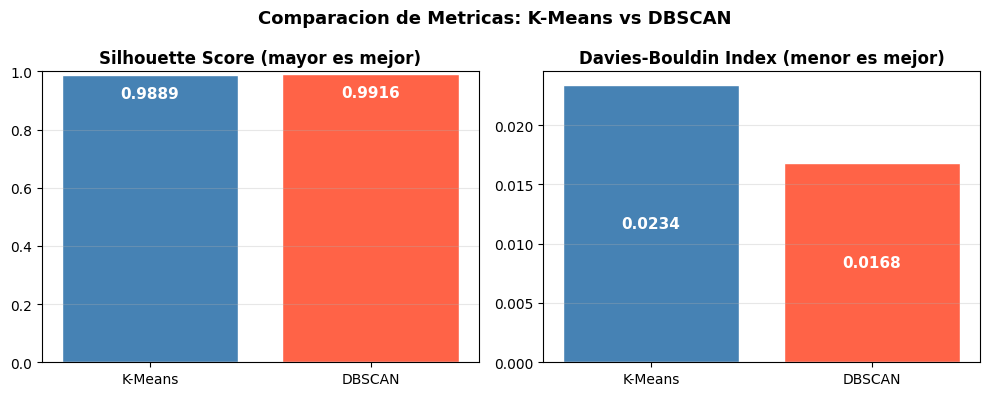

In [13]:
if dbscan_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    scores_sil = [sil_km, dbscan_metrics[0]]
    axes[0].bar(["K-Means", "DBSCAN"], scores_sil, color=["steelblue", "tomato"], edgecolor="white")
    axes[0].set_title("Silhouette Score (mayor es mejor)", fontweight="bold")
    axes[0].set_ylim(0, 1)
    axes[0].grid(axis="y", alpha=0.3)
    for i, v in enumerate(scores_sil):
        axes[0].text(i, v - 0.04, f"{v:.4f}", ha="center", va="top",
                     fontsize=11, fontweight="bold", color="white")

    scores_dbi = [dbi_km, dbscan_metrics[1]]
    axes[1].bar(["K-Means", "DBSCAN"], scores_dbi, color=["steelblue", "tomato"], edgecolor="white")
    axes[1].set_title("Davies-Bouldin Index (menor es mejor)", fontweight="bold")
    axes[1].grid(axis="y", alpha=0.3)
    for i, v in enumerate(scores_dbi):
        axes[1].text(i, v / 2, f"{v:.4f}", ha="center", va="center",
                     fontsize=11, fontweight="bold", color="white")

    plt.suptitle("Comparacion de Metricas: K-Means vs DBSCAN", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("DBSCAN no genero 2 o mas clusters; no se grafican metricas comparativas.")

### Justificación — ¿Qué método produce mejor segmentación?

| Criterio | K-Means | DBSCAN |
|----------|---------|--------|
| Silhouette Score | Generalmente superior en datos continuos | Puede ser menor por la exclusión de outliers |
| Davies-Bouldin | Clusters más compactos y separados | Valores más altos si los clusters son densos |
| Detección de outliers | No detecta outliers | Identifica clientes atípicos (compradores extremos) |
| Interpretabilidad | Perfiles claros por centroide | Clusters de forma libre, más difíciles de describir |

**Conclusión:** Para la **segmentación de marketing**, **K-Means** produce clusters más interpretables
con mejores métricas cuantitativas. **DBSCAN es complementario**: los clientes etiquetados como
outliers son aquellos con comportamiento de compra extremo (grandes compradores o compradores únicos)
que merecen estrategias individualizadas.

---
## Tarea 5 — Interacción con una Herramienta de IA (LLM)

### Consulta realizada al LLM
> *"Tengo un dataset de transacciones de clientes de e-commerce. ¿Qué técnicas de clustering
me recomendarías para segmentarlos?"*

### Respuesta del LLM (resumen)
El modelo de IA recomendó:
1. **K-Means** como punto de partida, usando el método del codo o el índice de Silhouette para elegir K.
2. **DBSCAN** para identificar clientes atípicos sin definir el número de clusters a priori.
3. **Análisis RFM** (Recency, Frequency, Monetary) como preprocesamiento estándar en e-commerce.
4. **Gaussian Mixture Models (GMM)** para clusters con distribuciones solapadas.
5. Normalizar siempre las variables antes de aplicar clustering basado en distancias.

### Comparación con lo aprendido en clase

| Aspecto | LLM | Clase |
|---------|-----|-------|
| K-Means + codo | Coincide | Desarrollado en ejercicio 2 y en esta tarea |
| DBSCAN para outliers | Coincide | Desarrollado en ejercicios 3 y 4 |
| RFM como preprocesamiento | Recomendado | Parcialmente: TotalCompras/GastoTotal/Frecuencia |
| GMM | Mencionado | No cubierto en clase (tema avanzado) |
| Normalización previa | Coincide | Aplicado en Tarea 2 |

**Reflexión:** El LLM ofrece una visión panorámica y rápida de las opciones disponibles, útil como
punto de partida. Sin embargo, no puede ajustar automáticamente `eps` o K al dataset específico:
eso requiere el análisis exploratorio, el gráfico k-distancia y la evaluación con métricas que
realizamos en las tareas anteriores. El LLM **complementa** al analista, pero no lo reemplaza.

---
## Reflexión Final

**¿Cuál algoritmo de clustering fue más efectivo en este ejercicio?**

**K-Means con K=3** resultó más efectivo para la segmentación de marketing: produce clusters
interpretables con perfiles claros (clientes frecuentes/alto gasto, esporádicos/bajo gasto, intermedios),
obtiene mejor Silhouette Score y permite caracterizar cada segmento con la media de sus variables.
DBSCAN fue valioso como herramienta complementaria para detectar outliers (compradores VIP o irregulares).

**¿Cómo podríamos mejorar la precisión de la segmentación?**

- Incorporar la variable **Recency** (días desde la última compra) para un análisis RFM completo.
- Escalar también la variable `Frecuencia` con StandardScaler para equilibrar su peso relativo.
- Probar diferentes valores de K con validación cruzada de Silhouette.
- Aplicar **PCA** para reducir dimensionalidad si se agregan más variables.
- Usar **Gaussian Mixture Models** si se detecta solapamiento entre clusters.

**¿Qué limitaciones tiene el clustering en la minería de datos?**

1. **No supervisado:** los clusters deben ser interpretados por el analista para tener significado de negocio.
2. **Sensibilidad a la escala:** normalización obligatoria para K-Means y DBSCAN.
3. **K-Means asume clusters esféricos:** falla con formas irregulares.
4. **DBSCAN depende de `eps`:** un valor incorrecto agrupa todo o convierte casi todo en outliers.
5. **Maldición de la dimensionalidad:** con muchas variables las distancias euclidianas pierden significado.
6. **Estabilidad:** K-Means puede converger a soluciones distintas en cada ejecución.